# Answers to Assignment 1

### Problem (unicode)
1. ```chr(0) = '\x00'```
2. ```__repr__() = "'\\x00'"``` ,print prints nothing
3. The charecter ```\0``` is the end of string so the print doesnt print the escaped character it is hidden ig

In [ ]:
chr(0)

In [ ]:
print(chr(0))

In [ ]:
"this is a test" + chr(0) + "string"

In [ ]:
print("this is a test" + chr(0) + "string")

### Problem (unicode2)

1. Is it sparsity? Bigger encodings just waste token representations and increase the individual thing
2. ```こんにちは``` wont be decoded. The problem is that sometimes decode needs more than just one byte to get
3. ```b1000_1000_1000``` is an invalid byte sequence

In [ ]:
len("this is a cool string".encode('utf-8'))

In [ ]:
len("this is a cool string".encode('utf-16'))

In [ ]:
len("this is a cool string".encode('utf-32'))

In [ ]:
def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode("utf-8") for b in bytestring])

In [ ]:
decode_utf8_bytes_to_str_wrong("こんにちは")

### Problem (train_bpe_tinystories)
1. It took 265 MB and 2208.729ms to train the tokenizer. (26s for the chunking with 2.4 GB of collective memory on 24 cores). The longest words are  ```[accomplishment,disappointment, responsibility]``` which make senseish ig
2. ```cupsert`` My helper method to add and remove in the heap took a lot of time. The build_list helper took a major chunk in the start and then there were a lot of removals at the start accounting for 24% of the time and build list (initial heap initialization) accounting for 32% of the time

In [2]:
from cs336_basics.train.tokenizer import train_tokenizer
from cs336_basics.pretokenize import count_pretokens_mapper, count_pretokens_reducer, multiproc_pretokens
from functools import partial
from collections import Counter
import os
from cs336_basics.perf import pyspy_profile, PeakMoniter
import pickle
import time

TINY_STORIES = "data/TinyStoriesV2-GPT4-train.txt"
OWL = "data/owt_train.txt"
NPROC = os.cpu_count()
special_tokens = ["<|endoftext|>"]

Tiny Stories Profiling: 

In [2]:
print("Running count pretokenize profiling for TINY_STORIES:")
tiny_stories_pretoken_counter = Counter()
monitor = PeakMoniter()
monitor.start()
with pyspy_profile(output=f"profiles/tiny_stories_count_pretokens.json", rate=100):
    multiproc_pretokens(
        TINY_STORIES,
        partial(count_pretokens_mapper, end_token="<|endoftext|>"),
        count_pretokens_reducer,
        tiny_stories_pretoken_counter,
        numprocs=NPROC
    )

print(f"peak (rss,pss) for pretoken counting TINY_STORIES {monitor.stop()} MB")

In [3]:
print("Running train_tokenizer profiling for TINY_STORIES:")
monitor = PeakMoniter()
monitor.start()
start = time.perf_counter()
with pyspy_profile(output=f"profiles/tiny_stories_train_tokenizer.json", rate=100):
    v, m = train_tokenizer(10_000, ["<|endoftext|>"],tiny_stories_pretoken_counter)

print(f"training took {(time.perf_counter() - start) * 1000:.3f}ms")
print(f"peak (rss,pss) for training tokenizer on TINY_STORIES {monitor.stop()} MB")

with open("models/tiny_stories_tokenizer.pkl", "wb") as file:
    pickle.dump((v,m), file)

In [4]:
vocab = sorted(v.values(), key=len)
print("\n".join([v.decode(encoding='utf-8') for v in vocab if len(v) == len(vocab[-1])]))

### Problem (train_bpe_expts_owt)
1. It took 14.4 GB and 368.778s to train the tokenizer. (132s for the chunking with 10.3 GB of collective memory on 24 cores). The longest are  ```[ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ, ----------------------------------------------------------------]``` which probably come due to the fact that our vocabulary can fit much longer tokens
2. ```removals``` followed by a stream of adds was the trend for this. Tokenizer size was 732K roughly 3.3 times which follows perfectly from the vocab sizes. 

In [11]:
print("Running count pretokenize profiling for OWL:")
owl_pretoken_counter = Counter()
monitor = PeakMoniter()
monitor.start()
start = time.perf_counter()
with pyspy_profile(output=f"profiles/owl_count_pretokens.json", rate=100):
    multiproc_pretokens(
        OWL,
        partial(count_pretokens_mapper, end_token="<|endoftext|>"),
        count_pretokens_reducer,
        owl_pretoken_counter,
        numprocs=NPROC
    )

print(f"pretokening took {(time.perf_counter() - start):.3f}s")
print(f"peak (rss,pss) for pretoken counting OWL {monitor.stop()} MB")

In [12]:
print("Running train_tokenizer profiling for OWL:")
monitor = PeakMoniter()
monitor.start()
start = time.perf_counter()

with pyspy_profile(output=f"profiles/owl_train_tokenizer.json", rate=100):
    v, m = train_tokenizer(32_000, ["<|endoftext|>"],owl_pretoken_counter)
    
print(f"training took {(time.perf_counter() - start):.3f}s")
print(f"peak (rss,pss) for training tokenizer on OWL {monitor.stop()} MB")
with open("models/owl_tokenizer.pkl", "wb") as file:
    pickle.dump((v,m), file)

In [13]:
vocab = sorted(v.values(), key=len)
print("\n".join([v.decode(encoding='utf-8') for v in vocab if len(v) == len(vocab[-1])]))

### Problem (tokenizer_experiments)
1. The compression ratio is about 4 for all tokenizer with owl performing the best on its own set with 4.3
2. Owl performs well reaching 3.9 on tiny token but tiny tok fails at 3.1 which shows that tiny tokenizers vocab isn't big enough to compress owl's tokens
3. Throughput of my tokenizer is 13 MB/s. Pile Dataset would take 18 Hours. Note that this is using 24 cores
4. uint16 is an apt choice because it is the nearest power of 2 which allows for the tokenizers tokens to fit (technically 2^15) fits but well we like even bits :)

In [1]:
import math
print(825 * (2 ** 10) / 13 / 60/60)
print(math.ceil(math.log2(32_000)))

In [2]:
from cs336_basics.tokenizer import BPETokenizer

owl_tok = BPETokenizer.from_file('models/owl_tokenizer.pkl')
tiny_tok = BPETokenizer.from_file('models/tiny_stories_tokenizer.pkl')
TINY_STORIES = "data/TinyStoriesV2-GPT4-train.txt"
OWL = "data/owt_train.txt"


In [3]:
from random import shuffle
with open(TINY_STORIES, "r") as tiny: 
    tiny_10_docs = tiny.read(4096 * 100).split('<|endoftext|>')
    shuffle(tiny_10_docs)
    tiny_10_docs = tiny_10_docs[:10]

with open(OWL, "r") as owl: 
    owl_10_docs = owl.read(4096 * 100).split('<|endoftext|>')
    shuffle(owl_10_docs)
    owl_10_docs = owl_10_docs[:10]


In [4]:
[doc[:100]+'...' for doc in tiny_10_docs][:3]

In [5]:
[doc[:100]+'...' for doc in owl_10_docs][:3]

In [6]:
import numpy as np
def compression_ratio(tokenizer: BPETokenizer, doc: str): 
    doc_b = doc.encode('utf-8')
    encoded = tokenizer.encode(doc)
    return len(doc_b) / len(encoded)

owl_v_owl = [compression_ratio(owl_tok, owl_doc) for owl_doc in owl_10_docs]
tiny_v_owl = [compression_ratio(tiny_tok, owl_doc) for owl_doc in owl_10_docs]
owl_v_tiny = [compression_ratio(owl_tok, tiny_doc) for tiny_doc in tiny_10_docs]
tiny_v_tiny = [compression_ratio(tiny_tok, tiny_doc) for tiny_doc in tiny_10_docs]

In [7]:
from statistics import mean, stdev

print(f"owl_v_owl  : mean = {mean(owl_v_owl):.3f} stdev = {stdev(owl_v_owl):.3f}")
print(f"owl_v_tiny : mean = {mean(owl_v_tiny):.3f} stdev = {stdev(owl_v_tiny):.3f}")
print(f"tiny_v_owl : mean = {mean(tiny_v_owl):.3f} stdev = {stdev(tiny_v_owl):.3f}")
print(f"tiny_v_tiny: mean = {mean(tiny_v_tiny):.3f} stdev = {stdev(tiny_v_tiny):.3f}")

In [1]:
import time
import os 
from cs336_basics.pretokenize import multiproc_pretokens, SPECIAL_EOT_TOKEN, encode_pretokenize_reducer, encode_pretokenize_mapper
from functools import partial
import numpy as np
from cs336_basics.perf import PeakMoniter, pyspy_profile

NPROC = os.cpu_count()

In [ ]:
start = time.perf_counter()
file = "data/owt_valid.txt"
encoded_file = []

multiproc_pretokens(
    file,
    partial(encode_pretokenize_mapper, tokenizer=owl_tok),
    encode_pretokenize_reducer,
    encoded_file,
    numprocs=NPROC
)

walltime = time.perf_counter() - start
print(f"training took {walltime:.3f}s")


print(f"OWL throughput: { os.path.getsize(file) / walltime / 1e6: .3f} MB / s")

In [ ]:
file_tokenized = np.concatenate([arr for _, arr in sorted(encoded_file, key=lambda x: x[0])])
np.save("data/tokenized/owl_valid_tokens_with_owl.npy", file_tokenized) 

### Problem (transformer_accounting)
1. Architecture counting:
```python
vocab_size = 50_257
max_context = 1_024
num_layers = 48
d_model = 1600
num_heads = 25
d_ff = 4_288

# Transformer is: token -> [Embedding In] -> num_layers * { [Norm]-> {MHA} -> [Norm] -> SwiGLU} -> [Norm] -> [Linear Emb Out] -> Softmax
# MHA = num_heads * {Wq, Wk, Wv} ->  Wo -> X
# dk = d_model // num_heads, dv = d_model // numheads

dk = d_model // num_heads
dv = d_model // num_heads

MHA = num_heads * (d_model * dk + d_model * dk + d_model * dv) + d_model * (dv * num_heads)
TRANSFORMER = vocab_size * d_model + num_layers * (d_model + MHA + d_model + 3 * d_model * d_ff ) + d_model + d_model * vocab_size
```
This brings to 1640452800 or about 1.64 billion params
2. 
```python
tokens = max_context

# Embedding In -> 0 FLOPS
# Normalization: sqrt(aTa) + a / RMS(a) + a * y_i
#   brings 2 * d_model + d_model + d_model + d_model = 5 d_model flops per tokem == 5 * d_model * context
#              aTa         sqrt      /          * 
# MHA: [n_heads * ( softmax(xWq Wk.T x.T / sqrt(dk)) Wv x )]  Wo 
#   Q = XWq -- context * 2 * dmodel * dk
#   K = XWk -- context * 2 * dmodel * dk
#   V = XWv -- context * 2 * dmodel * dv
#   QK^T -- 2 * context * d_model * dk
#   /sqrt(dk) -- context * context
#   soft(...) -- context * 5 context 
#      softmax_per key: N  +  N  +  N  + N + N = 5N (N is context)
#                      max   sub   e^x  sum  /
#   soft(...)V -- 2 * context * dv
# ^ All done num_heads times

#   Final head combo
#   [....] Wv = num_heads * context * dv * dmodel

# (+) -> context * dmodel
# (RMS) -> 5 * d_model * context
# FFN -> W2 (W1 Swish(x) * W2 x) 
#     Swish = x/1+e-x -> 4 FLOPs
#     Swish(x) = context * dmodel * 4
#     W1 Swish(x) = 2 * context * d_model * d_ff
#     W2 x = 2 * context * d_model * d_ff
#     W1 Swish(x) * W2 = context * d_ff
#     W2 (...) = 2 * context * d_ff * d_model
# (+) -> context * dmodel

# Above ^ Num layer times
# Norm: 5 * context * d_model
# Linear out: 2 * vocab * d_model * context
# Softmax: 5 * context * vocab

FLOP_EMBEDD = 0
FLOP_NORM = 5 * context * d_model

FLOP_KQV = context * 2 * d_model * dk + context * 2 * d_model * dk + context * 2 * d_model* dv
FLOP_QKt = 2 * context * dk * context
FLOP_norm_dk = context * context
FLOP_Softmax = context * 5 * context
FLOP_SoftV = 2 * context * context * dv
FLOP_Wout = 2 * num_heads * context * dv * d_model
FLOP_MHA = num_heads * (FLOP_KQV + FLOP_QKt + FLOP_norm_dk + FLOP_Softmax + FLOP_SoftV) + FLOP_Wout

FLOP_ADD = context * d_model
FLOP_SWIGLU = context * d_model * 4 
FLOP_HADDAMARD = context * d_ff
FLOP_FFN = FLOP_SWIGLU + context * d_model * d_ff * (2 + 2) + FLOP_HADDAMARD + 2 * context * d_ff * d_model

FLOP_PER_LAYER = (FLOP_NORM + FLOP_MHA + FLOP_ADD + FLOP_NORM + FLOP_FFN + FLOP_ADD)
FLOP_LAYERS = FLOP_PER_LAYER * num_layers

FINAL_NORM = 5 * context * d_model
LINEAR_OUT = 2 * vocab_size * d_model * context
SOFT_MAX_FLOP = 5 * context * vocab_size

TRANSFORMER_FLOP_LOGIT = FLOP_EMBEDD + FLOP_LAYERS + FINAL_NORM + LINEAR_OUT
TRANSFORMER_FLOP_PROBS = TRANSFORMER_FLOP_LOGIT + SOFT_MAX_FLOP

MATMUL_FLOPS = num_layers * (num_heads * (FLOP_KQV + FLOP_QKt + FLOP_SoftV) + FLOP_Wout + FLOP_FFN - FLOP_SWIGLU - FLOP_HADDAMARD) + LINEAR_OUT

```
Which gets to the following flops: 
- Without final softmax: 3.525796888576 TFLOPS
- With final softmax: 3.526054204416 TFLOPS
- Only Matmuls: 3.5167698944 TFLOPS

3. Matmul breakdown:
- MHA: K,Q,V 0.25165824 TFLOPs each | QKt 0.1610612736 TFLOPs | soft(...) V 0.1610612736 TFLOPs | Wout 0.25165824 TFLOPs
- FFN: W1 Swiglu(x), W3 x, W2 (...) 0.6744440832 TFLOPs
- LINEAR: 0.1646821376 TFLOPS

Notice that KQV calculation take about 0.75 TFLOPs and the FFN calculation takes ~1.9 TFLOPs which accounts for more than 50% so yeah FFN layer takes most flops

4. Yeah... FFN grows by a lot
5. increasing context increasing contri for attention (almost 70% goes here now was 30% previously)


In [2]:
vocab_size = 50_257
max_context = 1_024
num_layers = 48
d_model = 1600
num_heads = 25
d_ff = 4_288
context = 1_024

# Transformer is: token -> [Embedding In] -> num_layers * { [Norm]-> {MHA} -> [Norm] -> SwiGLU} -> [Norm] -> [Linear Emb Out] -> Softmax
# MHA = num_heads * {Wq, Wk, Wv} ->  Wo -> X
# dk = d_model // num_heads, dv = d_model // numheads

dk = d_model // num_heads
dv = d_model // num_heads

MHA = num_heads * (d_model * dk + d_model * dk + d_model * dv) + d_model * (dv * num_heads)
TRANSFORMER = vocab_size * d_model + num_layers * (d_model + MHA + d_model + 3 * d_model * d_ff ) + d_model + d_model * vocab_size

In [3]:
TRANSFORMER

In [4]:
FLOP_EMBEDD = 0
FLOP_NORM = 5 * context * d_model

FLOP_KQV = context * 2 * d_model * dk + context * 2 * d_model * dk + context * 2 * d_model* dv
FLOP_QKt = 2 * context * dk * context
FLOP_norm_dk = context * context
FLOP_Softmax = context * 5 * context
FLOP_SoftV = 2 * context * context * dv
FLOP_Wout = 2 * num_heads * context * dv * d_model
FLOP_MHA = num_heads * (FLOP_KQV + FLOP_QKt + FLOP_norm_dk + FLOP_Softmax + FLOP_SoftV) + FLOP_Wout

FLOP_ADD = context * d_model
FLOP_SWIGLU = context * d_model * 4 
FLOP_HADDAMARD = context * d_ff
FLOP_FFN = FLOP_SWIGLU + context * d_model * d_ff * (2 + 2) + FLOP_HADDAMARD + 2 * context * d_ff * d_model

FLOP_PER_LAYER = (FLOP_NORM + FLOP_MHA + FLOP_ADD + FLOP_NORM + FLOP_FFN + FLOP_ADD)
FLOP_LAYERS = FLOP_PER_LAYER * num_layers

FINAL_NORM = 5 * context * d_model
LINEAR_OUT = 2 * vocab_size * d_model * context
SOFT_MAX_FLOP = 5 * context * vocab_size

TRANSFORMER_FLOP_LOGIT = FLOP_EMBEDD + FLOP_LAYERS + FINAL_NORM + LINEAR_OUT
TRANSFORMER_FLOP_PROBS = TRANSFORMER_FLOP_LOGIT + SOFT_MAX_FLOP

MATMUL_FLOPS = num_layers * (num_heads * (FLOP_KQV + FLOP_QKt + FLOP_SoftV) + FLOP_Wout + FLOP_FFN - FLOP_SWIGLU - FLOP_HADDAMARD) + LINEAR_OUT

In [5]:
print(f"""Which gets to the following flops: 
- Without final softmax: {TRANSFORMER_FLOP_LOGIT/1e12} TFLOPS
- With final softmax: {TRANSFORMER_FLOP_PROBS/1e12} TFLOPS
- Only Matmuls: {MATMUL_FLOPS/1e12} TFLOPS""")

In [8]:
print(f"""Matmul breakdown:
- MHA: K,Q,V {num_layers * num_heads * FLOP_KQV / 3 / 1e12} TFLOPs each | QKt {num_layers *num_heads* FLOP_QKt / 1e12} TFLOPs | soft(...) V {num_layers * num_heads * FLOP_SoftV/ 1e12} TFLOPs | Wout {num_layers * FLOP_Wout/ 1e12} TFLOPs
- FFN: W1 Swiglu(x), W3 x, W2 (...) {num_layers * (FLOP_FFN - FLOP_SWIGLU - FLOP_HADDAMARD) /3 / 1e12} TFLOPs
- LINEAR: {LINEAR_OUT / 1e12} TFLOPS
""")

In [ ]:
def transformer_params(
    vocab_size,
    d_model,
    num_layers,
    num_heads,
    d_ff,
    dk=None,
    dv=None,
    **_,                      # swallow context/name/etc so you can pass a full config dict
):
    dk = d_model // num_heads if dk is None else dk
    dv = d_model // num_heads if dv is None else dv

    MHA = num_heads * (d_model * dk + d_model * dk + d_model * dv) + d_model * (dv * num_heads)
    embed_in = vocab_size * d_model
    embed_out = d_model * vocab_size
    per_layer = d_model + MHA + d_model + 3 * d_model * d_ff   # 2 norms + attn + swiglu
    total = embed_in + num_layers * per_layer + d_model + embed_out

    return {
        "total": total,
        "embedding": embed_in + embed_out,
        "non_embedding": total - embed_in - embed_out,
    }


def transformer_flops(
    name,
    vocab_size,
    context,
    d_model,
    num_layers,
    num_heads,
    d_ff,
    dk=None,
    dv=None,
):
    dk = d_model // num_heads if dk is None else dk
    dv = d_model // num_heads if dv is None else dv

    # ---- attention, per layer ----
    FLOP_KQV = (context * 2 * d_model * dk) * 2 + context * 2 * d_model * dv
    FLOP_QKt = 2 * context * dk * context
    FLOP_norm_dk = context * context
    FLOP_Softmax = context * 5 * context
    FLOP_SoftV = 2 * context * context * dv
    FLOP_Wout = 2 * num_heads * context * dv * d_model
    FLOP_MHA = (
        num_heads * (FLOP_KQV + FLOP_QKt + FLOP_norm_dk + FLOP_Softmax + FLOP_SoftV)
        + FLOP_Wout
    )

    # ---- ffn, per layer (SwiGLU, 3 matmuls) ----
    FLOP_SWIGLU = context * d_model * 4          # activation term (technically over d_ff)
    FLOP_HADDAMARD = context * d_ff
    FLOP_FFN = (
        FLOP_SWIGLU
        + context * d_model * d_ff * 4           # W1 + W3 up-projections
        + FLOP_HADDAMARD
        + 2 * context * d_ff * d_model           # W2 down-projection
    )

    # ---- other per-layer ----
    FLOP_NORM = 5 * context * d_model
    FLOP_ADD = context * d_model

    FLOP_PER_LAYER = FLOP_NORM + FLOP_MHA + FLOP_ADD + FLOP_NORM + FLOP_FFN + FLOP_ADD
    FLOP_LAYERS = FLOP_PER_LAYER * num_layers

    FINAL_NORM = 5 * context * d_model
    LINEAR_OUT = 2 * vocab_size * d_model * context

    total_logit = FLOP_LAYERS + FINAL_NORM + LINEAR_OUT

    attn_total = num_layers * FLOP_MHA
    ffn_total = num_layers * FLOP_FFN
    out_total = LINEAR_OUT
    matmul = (
        num_layers
        * (
            num_heads * (FLOP_KQV + FLOP_QKt + FLOP_SoftV)
            + FLOP_Wout
            + FLOP_FFN - FLOP_SWIGLU - FLOP_HADDAMARD
        )
        + LINEAR_OUT
    )

    p = transformer_params(vocab_size, d_model, num_layers, num_heads, d_ff, dk, dv)

    return {
        "model": name,
        "d_model": d_model,
        "n_layers": num_layers,
        "n_heads": num_heads,
        "d_ff": d_ff,
        "context": context,
        "params_M": round(p["total"] / 1e6, 1),
        "non_emb_M": round(p["non_embedding"] / 1e6, 1),
        "emb_param_%": round(100 * p["embedding"] / p["total"], 1),
        "total_TFLOP": round(total_logit / 1e12, 4),
        "attn_%": round(100 * attn_total / total_logit, 1),
        "ffn_%": round(100 * ffn_total / total_logit, 1),
        "out_%": round(100 * out_total / total_logit, 1),
        "matmul_%": round(100 * matmul / total_logit, 1),
        # cross-check: forward matmul FLOPs vs the 2N rule of thumb (~1.0, drifts up with context)
        "2N_ratio": round(matmul / (2 * context * (p["total"] - vocab_size * d_model)), 3),
    }


def flop_table(configs):
    return [transformer_flops(**c) for c in configs]


if __name__ == "__main__":
    # SwiGLU family: d_ff ~= 8/3 * d_model, XL pinned to 4288 per the assignment
    gpt2 = [
        dict(name="small",  vocab_size=50257, context=1024, d_model=768,  num_layers=12, num_heads=12, d_ff=2048),
        dict(name="medium", vocab_size=50257, context=1024, d_model=1024, num_layers=24, num_heads=16, d_ff=2730),
        dict(name="large",  vocab_size=50257, context=1024, d_model=1280, num_layers=36, num_heads=20, d_ff=3413),
        dict(name="xl",     vocab_size=50257, context=1024, d_model=1600, num_layers=48, num_heads=25, d_ff=4288),
    ]
    rows = flop_table(gpt2)
    cols = list(rows[0].keys())
    print("  ".join(f"{c:>11}" for c in cols))
    for r in rows:
        print("  ".join(f"{str(r[c]):>11}" for c in cols))

In [ ]:
from cs336_basics.layers import Transformer

t = Transformer(
    vocab_size=vocab_size,
    d_model = d_model,
    num_layers = num_layers,
    num_heads = num_heads,
    d_ff = d_ff
)

sum(p.numel() for p in t.parameters())

### Problem (learning_rate_tuning)

- 1e1 almost converges, 1e2 converges well, 1e3 blows up to infinity


In [6]:
import torch
from cs336_basics.layers import AdamW

LR = 1
weights = torch.nn.Parameter(5 * torch.randn((10,10)))
opt = AdamW([weights], lr=LR, weight_decay=0.02)
for t in range(101):
    opt.zero_grad()
    loss = (weights ** 2).mean()
    if t % 10 == 0:
        print(f"Loss {t}: {loss.cpu().item()}")
    loss.backward()
    opt.step()

### Problem (adam_accounting)

1. 
```python
def calc(vocab_size, context_length, num_layers, d_model, num_heads):
    d_ff = math.ceil(8/3 * d_model)
    
    L = num_layers
    V = vocab_size
    
    S = context_length
    D = d_model
    F = d_ff
    H = num_heads
    
    
    # Transformer block
    
    # Activations
    RMS1 = S * D # output of rms1
    Q = S * D
    K = S * D
    Vp = S * D
    Soft = 0 # dont save Q @ K.T because we can get dL/dS = A ⨀ (dL/dA ⨀ sum(dL/dA ⨀ A, dim = -1))
    A = H * S * S # Sequence square time numheads
    O = S * D
    Wout = S * D
    
    RMS2 = S * D
    
    W1X = S * F
    Swig = S * F
    W2X = S * F
    W3 = S * D
    
    # .... 
    FNORM = S * D
    LNORM = S * V
    
    
    # Params
    Y1 = D
    Wq = D * D
    Wk = D * D
    Wv = D * D
    Wo = D * D
    Y2 = D
    W1 = W2 = W3 = D * F
    
    Yend = D
    Lout = D * V
    
    
    ACTIVATIONS = L * (RMS1 + Q + K + Soft + A + Vp + O + Wout + RMS2 + W1X + Swig + W2X + W3) + FNORM + LNORM
    PARAMS = L * (Y1 + Wq + Wk + Wv + Wo + Y2 + W1 + W2 + W3) + Lout + Yend
    GRADS = PARAMS
    OPT = 2 * PARAMS
    return (ACTIVATIONS, PARAMS, GRADS, OPT)
```
2. ```batch_size = 2``` for GPT_XL so ```33.675 * (2) + 12.65```

In [12]:
import math
import torch
def calc(vocab_size, context_length, num_layers, d_model, num_heads):
    d_ff = math.ceil(8/3 * d_model)
    
    L = num_layers
    V = vocab_size
    
    S = context_length
    D = d_model
    F = d_ff
    H = num_heads
    
    
    # Transformer block
    
    # Activations
    RMS1 = S * D # output of rms1
    Q = S * D
    K = S * D
    Vp = S * D
    Soft = 0 # dont save Q @ K.T because we can get dL/dS = A ⨀ (dL/dA ⨀ sum(dL/dA ⨀ A, dim = -1))
    A = H * S * S # Sequence square time numheads
    O = S * D
    Wout = S * D
    
    RMS2 = S * D
    
    W1X = S * F
    Swig = S * F
    W2X = S * F
    W3 = S * D
    
    # .... 
    FNORM = S * D
    LNORM = S * V
    
    
    # Params
    Y1 = D
    Wq = D * D
    Wk = D * D
    Wv = D * D
    Wo = D * D
    Y2 = D
    W1 = W2 = W3 = D * F
    
    Yend = D
    Lout = D * V
    
    
    ACTIVATIONS = L * (RMS1 + Q + K + Soft + A + Vp + O + Wout + RMS2 + W1X + Swig + W2X + W3) + FNORM + LNORM
    PARAMS = L * (Y1 + Wq + Wk + Wv + Wo + Y2 + W1 + W2 + W3) + Lout + Yend
    GRADS = PARAMS
    OPT = 2 * PARAMS
    return (ACTIVATIONS, PARAMS, GRADS, OPT)

In [23]:
mem_gb = 4 * sum(calc(50_257,1_024,48,1_600,25)) / 2**30

In [26]:
80 // mem_gb, 80 % mem_gb

In [27]:
mem_gb

In [ ]:
def calc_ops(vocab_size, context_length, num_layers, d_model, num_heads):
    d_ff = math.ceil(8/3 * d_model)
    
    L = num_layers
    Vo = vocab_size
    
    S = context_length
    D = d_model
    F = d_ff
    H = num_heads


    emb = 2 * S * D * Vo

    rms1 = 5 * S * D # 1 + 1 + 1 + 1 + 1
    Q = 2 * S * D * D
    K = 2 * S * D * D
    QKTdk = H * S * S + 2 * S * D * S
    Soft = H * (S * S + S * S + S * S)
    V = 2 * S * D * D
    AV = 2 * S * S * D
    WO = 2 * S * D * D
    rms2 = 5 * S * D
    W1X = 2 * S * D * F
    Swi = 3 * S * F
    W2X = 2 * S * D * F
    Swi_W1X_W2X = S * F
    W3_ = 2 * S * F * D

    F_e = 5 * S * D
    L_o = 2 * S * Vo * D

    FORWARD = emb + L * (rms1 + Q + K + QKTdk + Soft + V + AV + WO + rms2 + W1X + Swi + W2X + Swi_W1X_W2X + W3_) + F_e + L_o
    
    BACKWARD = 2 * FORWARD
    
    

In [7]:
import matplotlib.pyplot as plt

def plot_losses(t_l, v_l, val_every=10, figsize=(9, 5), title="Training & Validation Loss"):

    t_l = t_l[1:]
    v_l = v_l[1:]
            
    fig, ax = plt.subplots(figsize=figsize)
    
    # train loss: one point per training step
    ax.plot(range(len(t_l)), t_l, label="train",
            color="#3b82f6", linewidth=1.5, alpha=0.9)

    # val loss logged every `val_every` steps, so stretch its x-coords to match
    v_x = [i * val_every for i in range(len(v_l))]
    ax.plot(v_x, v_l, label="val", color="#ef4444",
            linewidth=1.5, marker="o", markersize=4)

    ax.set_xlabel("training step")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax

# Model tests

## Basic
vocab = 32_000
d_model = 512
num_layers = 4
num_heads = 16
d_ff = 1344
context_length = 256

num_steps = 2000
batch_size = 16
theta = 10_000

In [10]:
from cs336_basics.layers import Transformer, training_together, RoPE, AdamW
import torch

vocab_size = 32_000
d_model = 512
num_layers = 4
num_heads = 16
d_ff = 1344
context_length = 256

num_steps = 2000
batch_size = 16


def cuda_if_available():
    return "cuda" if torch.cuda.is_available() else "cpu"


pos = RoPE(10_000, d_model // num_heads, context_length, device=cuda_if_available())
transformer = torch.compile(Transformer(
    vocab_size,
    d_model,
    num_layers,
    num_heads,
    d_ff,
    positional_encoding=pos,
    device=cuda_if_available(),
    dtype=torch.bfloat16,
))
optimizer = AdamW(transformer.parameters(), 1e-3, 1,(0.9, 0.999), 1e-8)


In [2]:
t_l, v_l = training_together(
    "data/tokenized/tiny_train_tokens_with_owl.npy",
    "data/tokenized/tiny_valid_tokens_with_owl.npy",
    context_length,
    batch_size,
    num_steps,
    transformer,
    optimizer,
    device=cuda_if_available(),
    checkpoint_every=10,
    checkpoint_prefix="models/basic",
)

Step:   0%|          | 0/2000 [00:00<?, ?it/s, train=inf, val=inf]/home/ddesai/projects/stanford-lectures/assignments/assignment1-basics/.venv/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Step: 100%|██████████| 2000/2000 [01:49<00:00, 18.22it/s, train=2.1562, val=1.9609] 


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Training & Validation Loss'}, xlabel='training step', ylabel='loss'>)

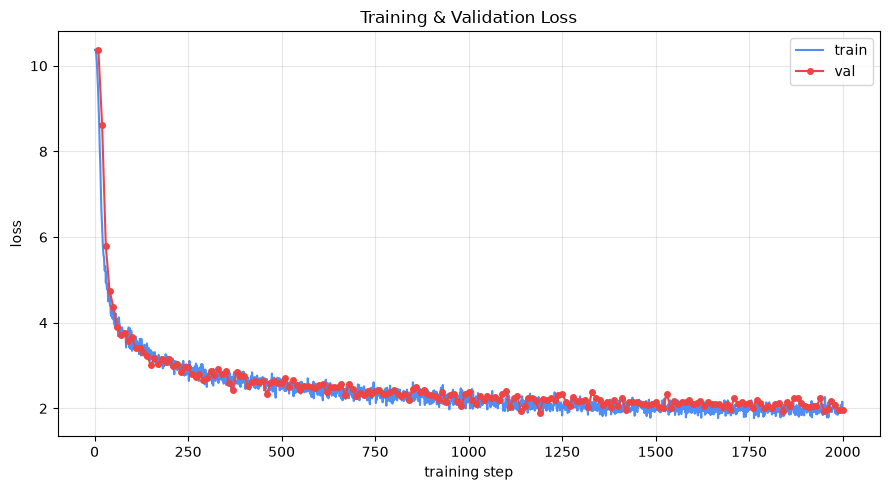

In [5]:
plot_losses(t_l, v_l)

## Learning rate Ablation

For this I will select the following LRs: 1e-3, 1, 10, 1000

In [ ]:
final_ls_vls = []

In [ ]:
for lr in [1e-4, 1e-5]:
    transformer_lr = torch.compile(
        Transformer(
            vocab_size,
            d_model,
            num_layers,
            num_heads,
            d_ff,
            positional_encoding=pos,
            device=cuda_if_available(),
            dtype=torch.bfloat16,
        )
    )
    optimizer = AdamW(transformer_lr.parameters(), lr, 1,(0.9, 0.999), 1e-8)
    t_l, v_l = training_together(
        "data/tokenized/tiny_train_tokens_with_owl.npy",
        "data/tokenized/tiny_valid_tokens_with_owl.npy",
        context_length,
        batch_size,
        1000,
        transformer_lr,
        optimizer,
        alph_max=lr,
        alph_min=lr/10,
        device=cuda_if_available(),
        checkpoint_every=1,
        checkpoint_prefix="models/basic",
    )
    final_ls_vls.append((t_l, v_l, lr))

Step: 100%|██████████| 1000/1000 [05:44<00:00,  2.91it/s, train=9.9375, val=9.9375] 


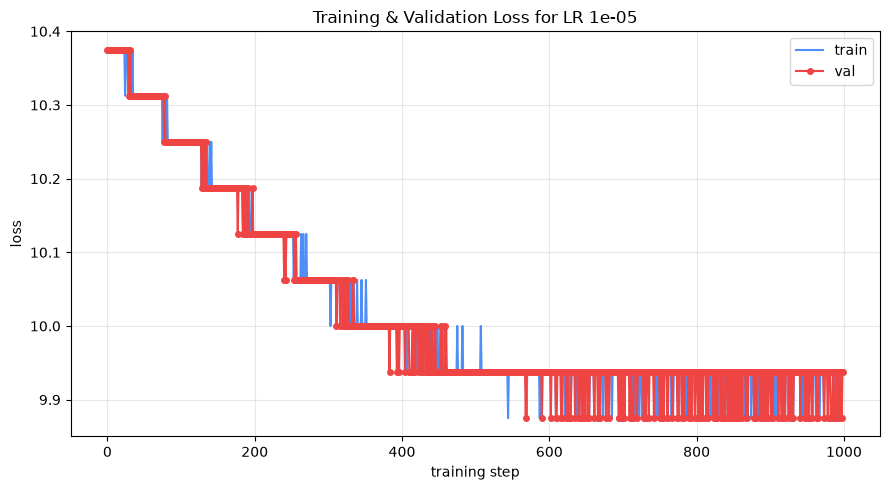

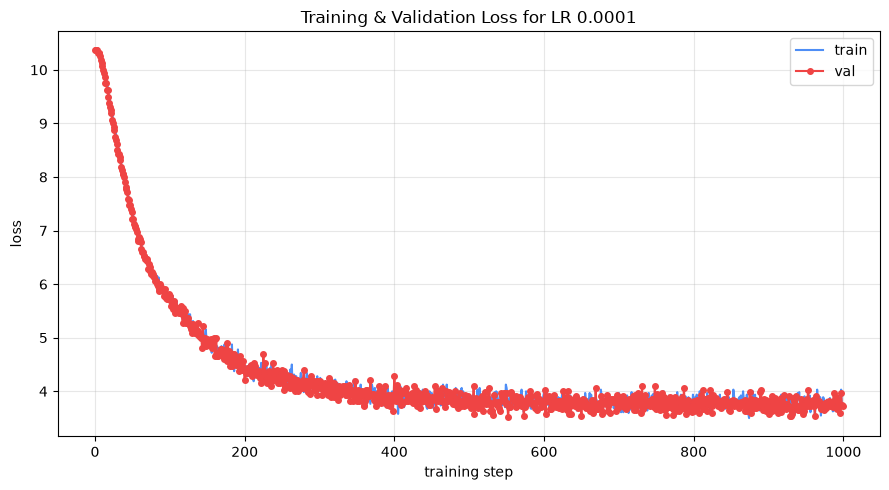

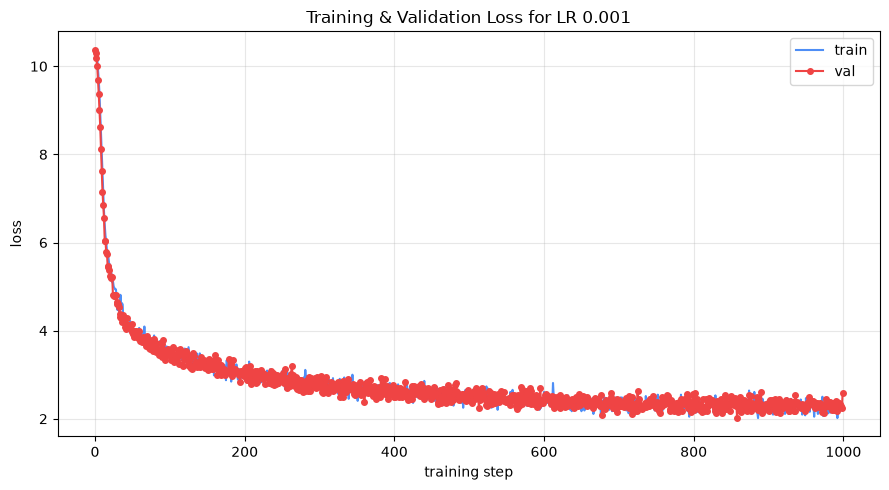

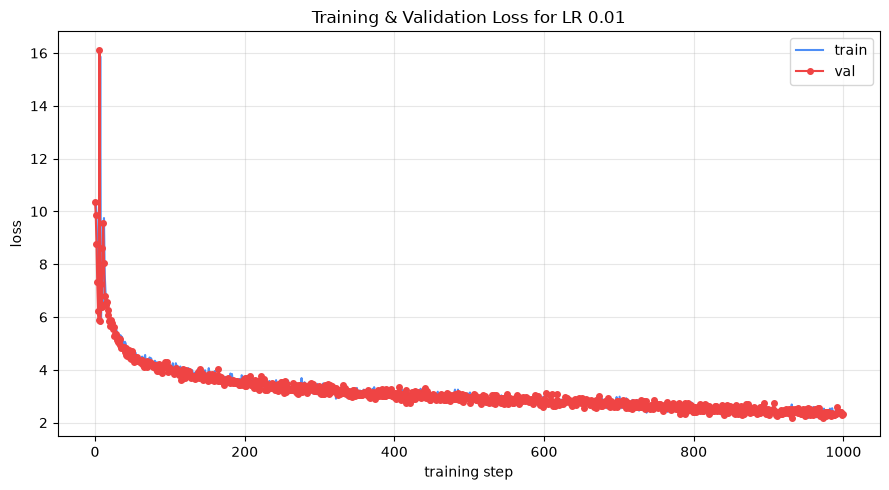

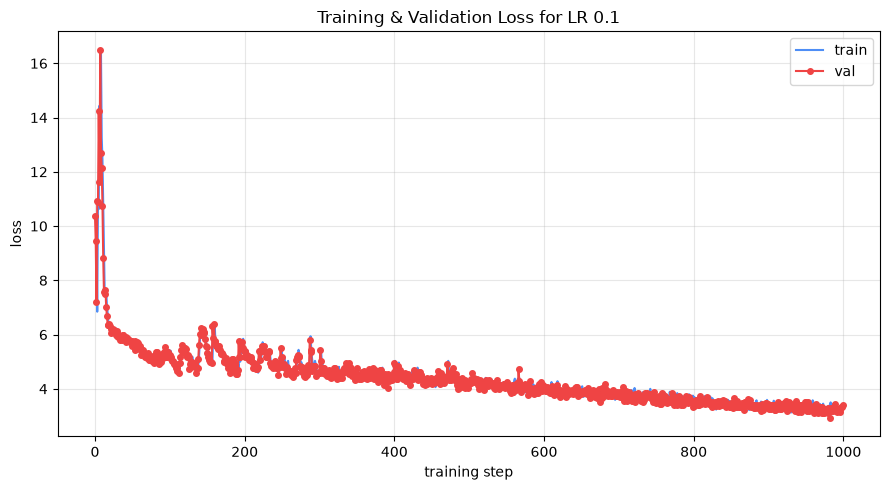

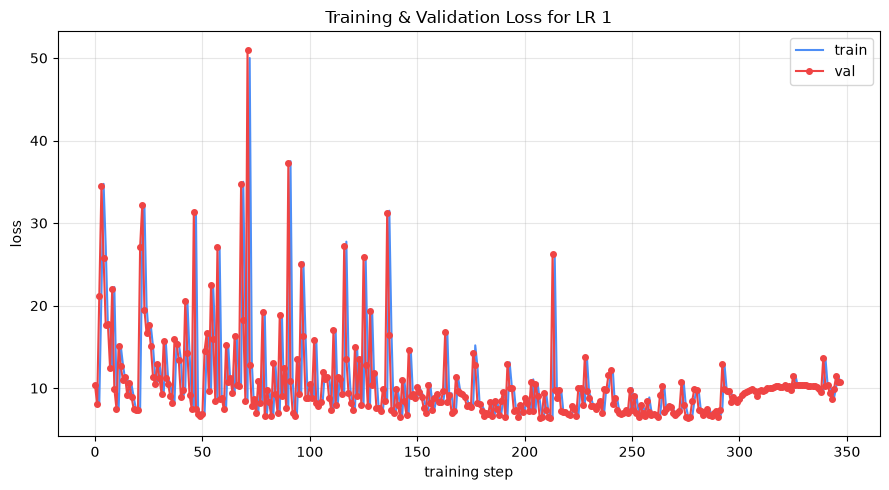

In [13]:
final_ls_vls = sorted(final_ls_vls, key=lambda x: x[2])
for t_l, v_l, lr in final_ls_vls:
    plot_losses(t_l, v_l,val_every=1, title=f"Training & Validation Loss for LR {lr}")

In [15]:
# Best LR for 1000 steps
final_ls_vls = sorted(final_ls_vls, key=lambda x: min(x[1]))
print([(x[2],min(x[1])) for x in final_ls_vls])

[(0.001, 2.015625), (0.01, 2.171875), (0.1, 2.921875), (0.0001, 3.515625), (1, 6.40625), (1e-05, 9.875)]


In [18]:
batch_loss_ablation = []
lr = 1e-3
for batch_size in [16,32,64,128]:
    transformer_batch = torch.compile(
        Transformer(
            vocab_size,
            d_model,
            num_layers,
            num_heads,
            d_ff,
            positional_encoding=pos,
            device=cuda_if_available(),
            dtype=torch.bfloat16,
        )
    )
    optimizer = AdamW(transformer_batch.parameters(), lr, 1,(0.9, 0.999), 1e-8)
    t_l, v_l = training_together(
        "data/tokenized/tiny_train_tokens_with_owl.npy",
        "data/tokenized/tiny_valid_tokens_with_owl.npy",
        context_length,
        batch_size,
        1000,
        transformer_batch,
        optimizer,
        alph_max=lr,
        alph_min=lr/10,
        device=cuda_if_available(),
        checkpoint_every=1,
        checkpoint_prefix="models/basic",
    )
    batch_loss_ablation.append((t_l, v_l, batch_size))    
    print(f"Batch Size: {batch_size}")
    print(torch.cuda.memory_summary())

Step: 100%|██████████| 1000/1000 [06:02<00:00,  2.76it/s, train=2.2188, val=2.1719]


Batch Size: 16
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 647455 KiB |   2352 MiB |  15583 GiB |  15583 GiB |
|       from large pool | 590016 KiB |   2300 MiB |  15173 GiB |  15172 GiB |
|       from small pool |  57439 KiB |     59 MiB |    410 GiB |    410 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 647455 KiB |   2352 MiB |  15583 GiB |  15583 GiB |
|       from large pool | 590016 KiB |   2300 MiB

Step:   0%|          | 0/1000 [00:00<?, ?it/s, train=inf, val=inf]/home/ddesai/projects/stanford-lectures/assignments/assignment1-basics/.venv/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Step: 100%|██████████| 1000/1000 [06:33<00:00,  2.54it/s, train=1.9688, val=2.1875] 


Batch Size: 32
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 645599 KiB |   4159 MiB |  24602 GiB |  24602 GiB |
|       from large pool | 588160 KiB |   4105 MiB |  24052 GiB |  24051 GiB |
|       from small pool |  57439 KiB |     64 MiB |    550 GiB |    550 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 645599 KiB |   4159 MiB |  24602 GiB |  24602 GiB |
|       from large pool | 588160 KiB |   4105 MiB

Step: 100%|██████████| 1000/1000 [07:03<00:00,  2.36it/s, train=1.7812, val=2.0625] 


Batch Size: 64
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 646687 KiB |   7773 MiB |  41183 GiB |  41182 GiB |
|       from large pool | 589248 KiB |   7721 MiB |  40493 GiB |  40492 GiB |
|       from small pool |  57439 KiB |     64 MiB |    689 GiB |    689 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 646687 KiB |   7773 MiB |  41183 GiB |  41182 GiB |
|       from large pool | 589248 KiB |   7721 MiB

Step: 100%|██████████| 1000/1000 [07:59<00:00,  2.09it/s, train=1.6719, val=1.9766]

Batch Size: 128
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 647263 KiB |  15000 MiB |  72799 GiB |  72798 GiB |
|       from large pool | 589824 KiB |  14944 MiB |  71964 GiB |  71963 GiB |
|       from small pool |  57439 KiB |     64 MiB |    834 GiB |    834 GiB |
|---------------------------------------------------------------------------|
| Active memory         | 647263 KiB |  15000 MiB |  72799 GiB |  72798 GiB |
|       from large pool | 589824 KiB |  14944 Mi

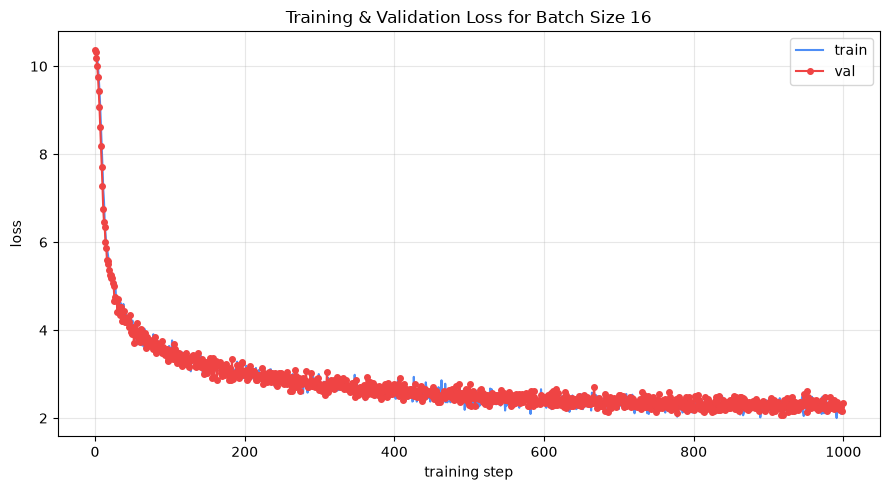

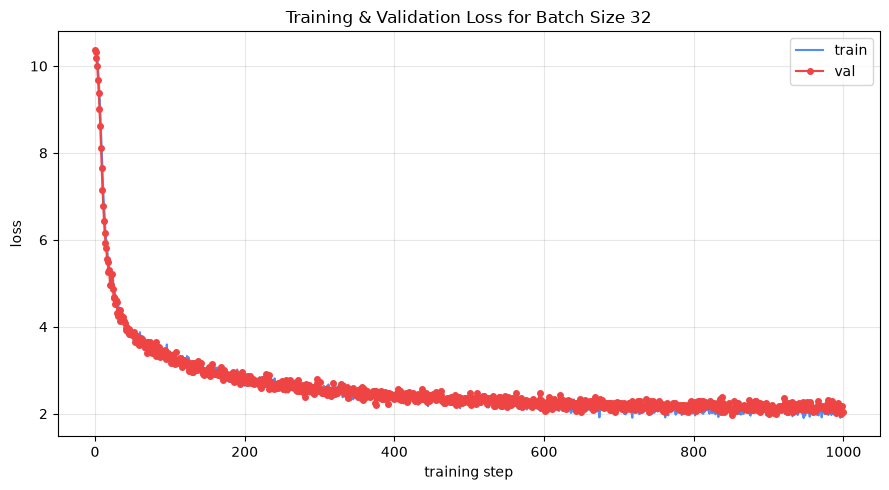

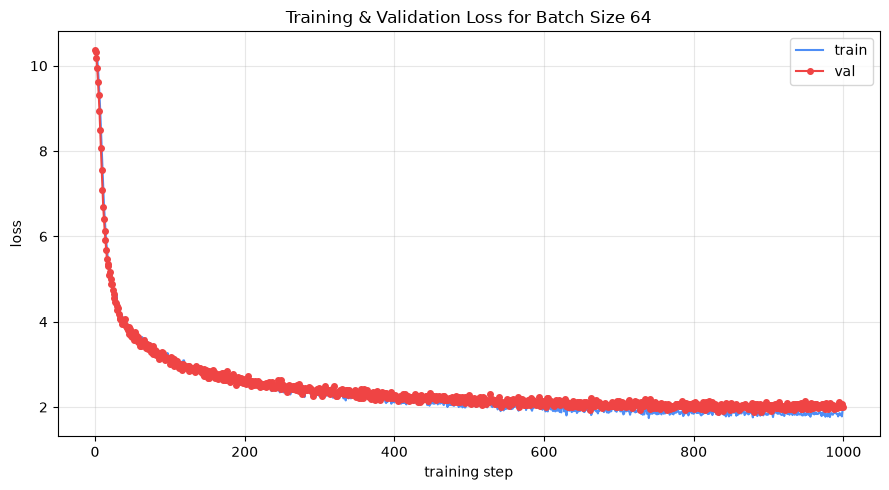

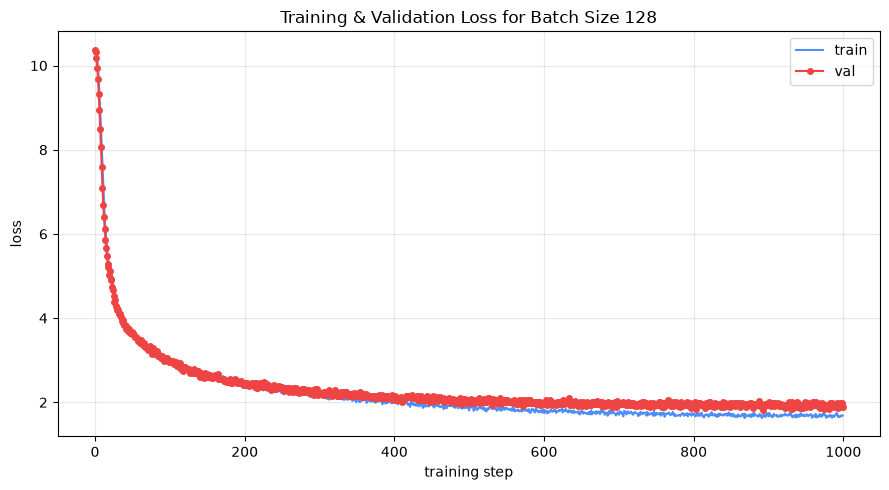

In [22]:
batch_loss_ablation = sorted(batch_loss_ablation, key=lambda x: x[2])
for t_l, v_l, bs in batch_loss_ablation:
    plot_losses(t_l, v_l,val_every=1, title=f"Training & Validation Loss for Batch Size {bs}")

In [21]:
# Best LR for 1000 steps
batch_loss_ablation = sorted(batch_loss_ablation, key=lambda x: min(x[1]))
print([(x[2],min(x[1]), min(x[0])) for x in batch_loss_ablation])

[(128, 1.8203125, 1.625), (64, 1.875, 1.7421875), (32, 1.96875, 1.8984375), (16, 2.078125, 2.0)]


# Final Model

lr = 8e-4
n_steps = 1_200
batch = 128

In [23]:
from cs336_basics.tokenizer import BPETokenizer
from cs336_basics.layers import decode

owl_tok = BPETokenizer.from_file('models/owl_tokenizer.pkl')

In [24]:
end_tok = owl_tok.to_token_id[b"<|endoftext|>"]

In [25]:
tokens = owl_tok.encode("Once")

while tokens[-1] != end_tok and len(tokens) < 256:
    tokens.append(decode(transformer_batch, torch.tensor(tokens, device=cuda_if_available())))

In [32]:
print(owl_tok.decode(tokens))

Once upon a time, there was a boy named Tim. Tim liked to play basketball game. One day, he found a big mess in his room. They both wanted it. The music made the music can.
Tim and his friends went to pick up the pieces together. Their moms came and gave them a big hug. "You found this fort!" Tim said. The friends were very happy that they had found a magic jar.
But Tim could not get the puzzle. He was sad. But then, something unexpected happened. The magic rope started to move and<|endoftext|>
Once upon a time, there was a grumpy raven. He liked to give many friends. One day, the boss came to me and all his friends. He was happy.
They walked and walked, looking for the pattern. Suddenly, the magic wand came and made the dirt shape up! The animals were very surprised. They had a trick on them.
The smallest frog told the magic crown to play with his friends. They all talked and played for a long time. They were happy she had made a new friend. And they lived happily ever after.
<|endoft

In [30]:
for k in tokens:
    if k == 256:
        print(k)

In [31]:
print(tokens)

[7229, 3066, 258, 631, 44, 593, 359, 258, 2911, 3320, 4870, 46, 4870, 7968, 284, 666, 7799, 933, 46, 1920, 1086, 44, 341, 1023, 258, 1111, 2035, 287, 460, 2195, 46, 1079, 1085, 2039, 340, 46, 393, 2346, 901, 262, 2346, 478, 46, 10, 14950, 294, 460, 2379, 1680, 284, 2165, 512, 262, 5361, 1900, 46, 5092, 28693, 1513, 294, 2775, 605, 258, 1111, 22844, 46, 488, 1811, 1023, 432, 6164, 5116, 4870, 481, 46, 393, 2379, 521, 846, 3601, 317, 474, 529, 1023, 258, 7419, 18759, 46, 10, 1302, 4870, 686, 408, 641, 262, 14598, 46, 688, 359, 5994, 46, 819, 811, 44, 1169, 9312, 2780, 46, 393, 7419, 18904, 1858, 284, 1334, 294, 60, 124, 441, 1868, 7801, 124, 62, 10, 7229, 3066, 258, 631, 44, 593, 359, 258, 965, 31331, 1645, 564, 46, 688, 7968, 284, 1596, 812, 2379, 46, 1920, 1086, 44, 262, 6288, 1513, 284, 511, 294, 486, 460, 2379, 46, 688, 359, 3601, 46, 10, 2521, 6673, 294, 6673, 44, 1947, 329, 262, 4196, 46, 25807, 44, 262, 7419, 14304, 1513, 294, 901, 262, 13537, 5522, 512, 33, 393, 4587, 521, 846, 6